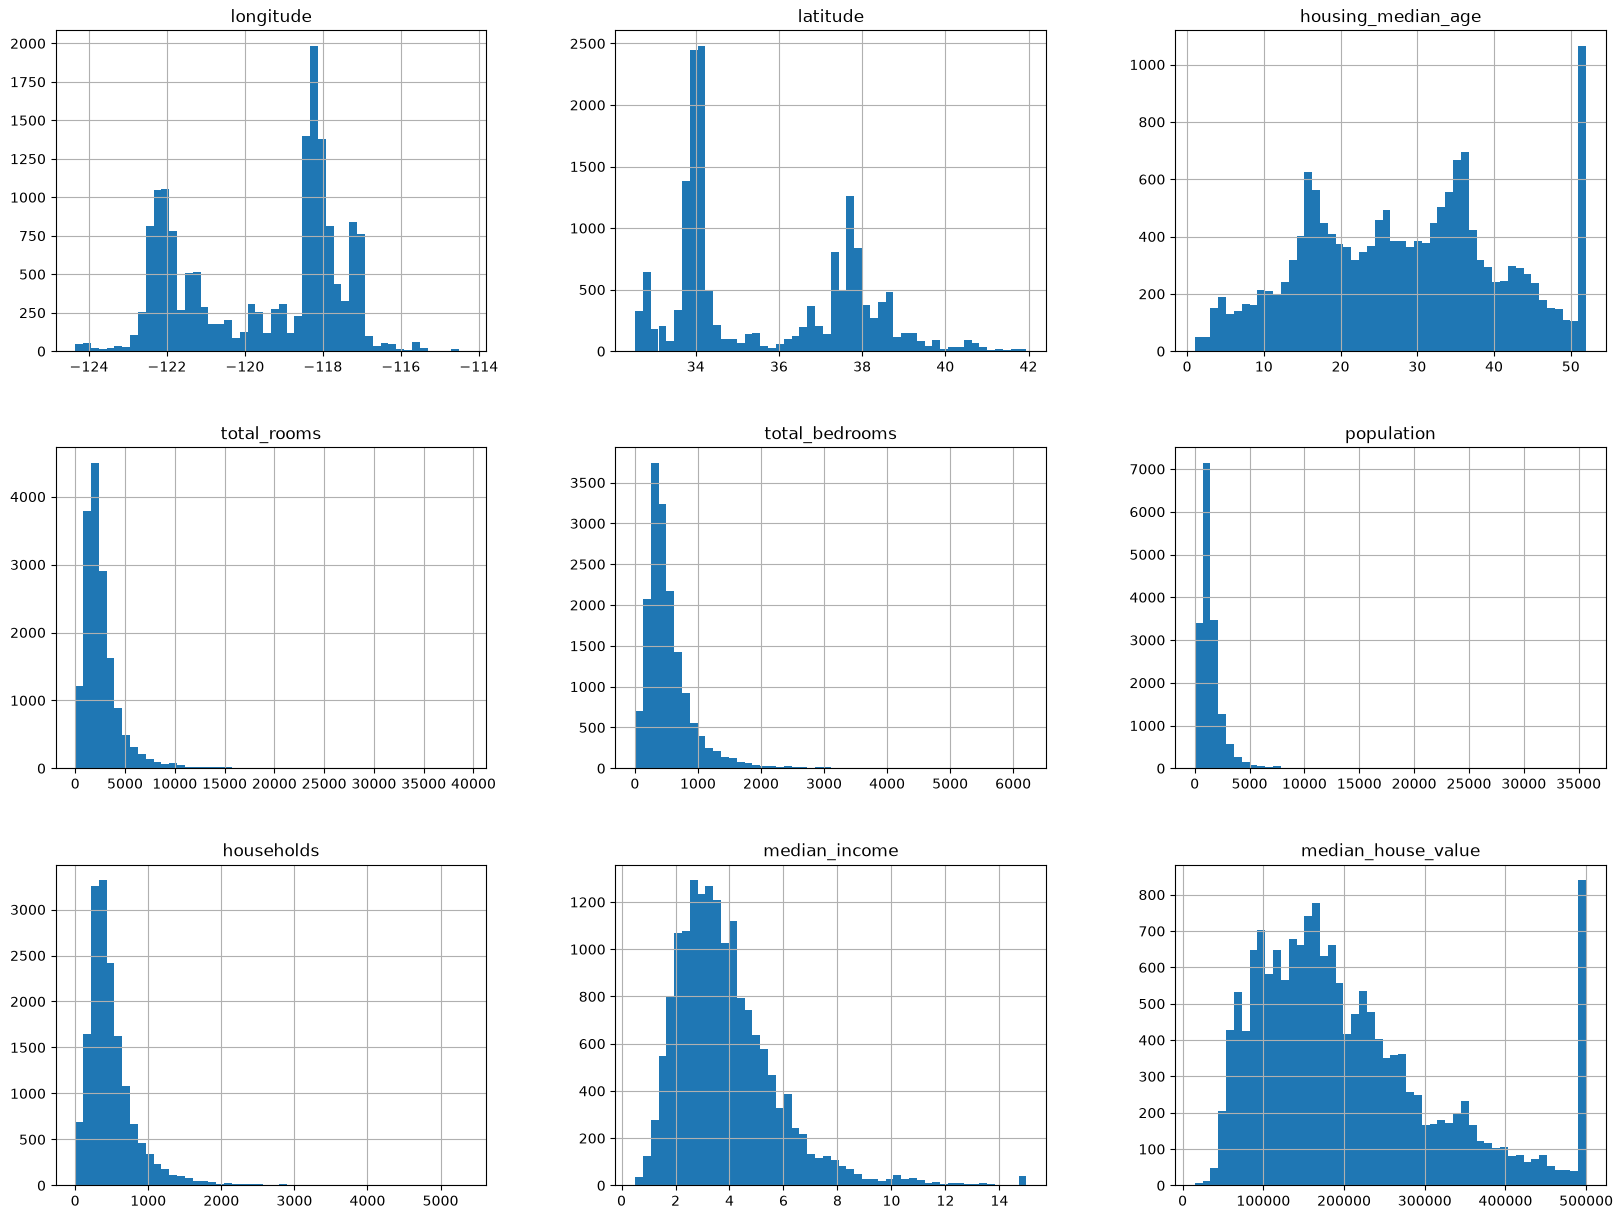

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816,500001.0,<1H OCEAN
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099,162500.0,<1H OCEAN
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839,204600.0,<1H OCEAN
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,159700.0,<1H OCEAN
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529,184000.0,NEAR OCEAN


In [6]:
import pandas as pd
from pandas.plotting import scatter_matrix
import os
import hashlib
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit 
%matplotlib inline
import matplotlib.pyplot as plt
HOUSING_РАТН = os.path.join("datasets" ,"housing")
def load_housing_data(housing_path=HOUSING_РАТН):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path) 
housing = load_housing_data()

#def test_set_check(identifier, test_ratio, hash):
#    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio
#def split_train_test_by_id(data, test_ratio, id_column, hash=hashlib.md5):
#    ids = data[id_column]
#    in_test_set = ids.apply(lambda id_:test_set_check(id_, test_ratio, hash)) !random sampling!
#   return data.loc[~in_test_set], data.loc[in_test_set]
#housing_with_id = housing.reset_index()
#housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
#train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)
housing["income_cat"] = housing["income_cat"].where(housing["income_cat"] < 5, 5.0)
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index] #!stratified sampling!
    strat_test_set = housing.loc[test_index] 
for set_ in(strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True) 

housing = strat_train_set.copy()
housing.hist(bins = 50 ,figsize = (20, 15))
plt.show()